In [ ]:
#from angle_emb import AnglE, Prompts
#from angle_emb.utils import cosine_similarity
import pandas as pd
import numpy as np
from tqdm import tqdm_notebook as tqdm
import matplotlib.pyplot as plt
import matplotlib
import json
import os
#import tiktoken
#from openai import OpenAI
import warnings
import networkx as nx
from itertools import combinations
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#tokenizer = tiktoken.encoding_for_model("gpt-4")

In [ ]:
comments = pd.read_csv('/content/drive/MyDrive/STATS547/Data/comments_climate_change.csv')
submissions = pd.read_csv('/content/drive/MyDrive/STATS547/Data/submissions_climate_change.csv')
all_content = pd.read_csv('/content/drive/MyDrive/STATS547/Data/all_content.csv')
subset_grouped_content=pd.read_csv('/content/drive/MyDrive/STATS547/Data/final_embedding_data.csv')

In [ ]:
#def get_batches():
#    batch_list_df = pd.DataFrame()
#    for i in client.batches.list():
#        temp_batch_df = pd.DataFrame([dict(i)])
#        batch_list_df = pd.concat([batch_list_df, temp_batch_df])
#    return batch_list_df

In [ ]:
submissions['selftext'] = submissions['selftext'].astype(str)
submissions['selftext'] = submissions['selftext'].apply(lambda x: x.replace('\n', ' '))
submissions.loc[submissions['selftext'] == 'nan', 'selftext'] = ''
submissions.loc[submissions['selftext'] == '[removed]', 'selftext'] = ''
submissions.loc[submissions['selftext'] == '[deleted]', 'selftext'] = ''
submissions['title'] = submissions['title'].astype(str)
submissions['title'] = submissions['title'].apply(lambda x: x.replace('\n', ' '))
submissions['scoring_text'] = submissions.apply(lambda x: x['title'] + ' ' + x['selftext'], axis=1)
submissions = submissions.loc[submissions['author'] != 'u/[deleted]']

In [ ]:
comments['body'] = comments['body'].astype(str)
comments.loc[comments['body'] == 'nan', 'body'] = ''
comments.loc[comments['body'] == '[removed]', 'body'] = ''
comments.loc[comments['body'] == '[deleted]', 'body'] = ''
comments['scoring_text'] = comments['body'].apply(lambda x: x.replace('\n', ' '))
comments = comments.loc[comments['author'] != 'u/[deleted]']

In [ ]:
#convert_to_embedding_jsonl(df=comments, subreddit='climatechange', file_format='_547_comments_part', FILE_PATH='JSONL/')
#files = [x for x in os.listdir('./JSONL/') if '.jsonl' in x]
#create_files(file_list=files, file_path='./JSONL/')
#file_list_df = get_files()

In [ ]:
#for filename in file_list_df.loc[file_list_df['filename'].str.contains('climatechange')]['id']:
#    batch_id = client.batches.create(
#        input_file_id=filename,
#        endpoint="/v1/embeddings",
#        completion_window="24h",
#        metadata={"batch_description": "ClimateChange547"}
#    )

In [ ]:
#batch_list_df = get_batches()

INFO:httpx:HTTP Request: GET https://api.openai.com/v1/batches "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.openai.com/v1/batches?after=batch_67fa7b4e544c819093443af845f5c10e "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.openai.com/v1/batches?after=batch_67fa7b4a81708190a2cf41823bce83f7 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.openai.com/v1/batches?after=batch_67fa7b458a1c8190acd4a9f307e919dc "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.openai.com/v1/batches?after=batch_67fa7b4167d08190b687cc0a10c19e59 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.openai.com/v1/batches?after=batch_67fa7b3d377081908a0da60f65d6bfe7 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.openai.com/v1/batches?after=batch_67fa7b3923988190a5fd49f47fa87c67 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.openai.com/v1/batches?after=batch_67fa7b350adc8190be3ba8cc55ff39cd "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://

In [ ]:
#def retrieve_results(files):
#    response_df = pd.DataFrame()
#    for file in files:
#        file_response = client.files.content(file)
#        content = file_response.content.decode("utf-8")
#        json_objects = content.splitlines()
#        parsed_objects = [json.loads(obj) for obj in json_objects]
#        responses = pd.DataFrame(parsed_objects)
#        responses['file'] = file
#        response_df = pd.concat([response_df, responses])
#
#    return response_df

In [ ]:
#embedding_df = retrieve_results(batch_list_df.loc[batch_list_df['metadata'].apply(lambda x: isinstance(x, dict) and 'batch_description' in x and x['batch_description'] == 'ClimateChange547')]['output_file_id'])

INFO:httpx:HTTP Request: GET https://api.openai.com/v1/files/file-1axm7bVcC5RFnWxmnVbVqr/content "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.openai.com/v1/files/file-AycHDSLapijZsemJPZLw8d/content "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.openai.com/v1/files/file-KTzpPTtkxMCjCeZNBhKdJb/content "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.openai.com/v1/files/file-7aaY9rakqf8h8JaG6JB3im/content "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.openai.com/v1/files/file-KVH1y6gELbPp7HzWSAh2w8/content "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.openai.com/v1/files/file-HbNsS5Zr4ubUR28BeBPu7Z/content "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.openai.com/v1/files/file-5BrXnEb8AECWPuEVFc3NDG/content "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.openai.com/v1/files/file-BAoncR6gEesJAiSthEpUP9/content "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.openai.com/v1/files/file-UeqdLYtweMsQjL

In [ ]:
#embedding_df['embedding'] = embedding_df['response'].apply(lambda x: x['body']['data'][0]['embedding'])

In [ ]:
#def normalize_l2(x):
#    x = np.array(x)
#    if x.ndim == 1:
#        norm = np.linalg.norm(x)
#        if norm == 0:
#            return x
#        return x / norm
#    else:
#        norm = np.linalg.norm(x, 2, axis=1, keepdims=True)
#        return np.where(norm == 0, x, x / norm)

In [ ]:
#doc_vecs = np.vstack(embedding_df['embedding'])
#doc_vecs_128 = doc_vecs[:, :128]
#normalized_vecs = normalize_l2(doc_vecs_128)
#expanded_vector_df = pd.DataFrame(normalized_vecs)

In [ ]:
#expanded_vector_df.head()

,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,-0.136540,0.062951,-0.092461,0.034690,0.033626,0.032493,0.054810,-0.003648,-0.049352,0.129510,...,0.092183,0.242553,0.020976,0.030759,0.101480,0.161795,-0.058603,0.084366,-0.094126,-0.260129
1,0.002132,-0.122776,-0.074979,0.034130,-0.044666,0.010129,-0.097426,-0.033443,-0.041460,-0.119620,...,0.040493,0.269780,0.108523,-0.009767,0.154844,0.038813,-0.012420,-0.060981,-0.035580,-0.085363
2,-0.051721,0.093902,-0.083237,-0.048372,-0.009688,0.064638,-0.013151,0.228110,-0.067425,0.138817,...,0.007912,-0.109660,-0.124024,0.068926,0.021841,0.118557,-0.174191,0.030550,-0.049068,0.000382
3,-0.030449,0.035878,-0.088257,-0.064070,0.010165,-0.018033,-0.027493,0.107231,0.047488,0.023166,...,0.055093,0.171462,-0.099975,0.140609,0.191027,0.097018,0.066220,0.012396,0.009406,-0.218976
4,0.017043,-0.048606,-0.057684,0.120744,0.003999,-0.063545,0.037699,-0.022056,-0.151503,0.035672,...,0.056582,0.180852,-0.015368,-0.034747,-0.020998,-0.022540,0.026308,-0.204472,-0.052925,-0.152825


In [ ]:
#expanded_vector_df = expanded_vector_df.reset_index(drop=True)
#embedding_df = embedding_df.reset_index(drop=True)

In [ ]:
#embedding_df_final = pd.concat([embedding_df, expanded_vector_df], axis=1)
#embedding_df_final = embedding_df_final.drop(columns=['embedding', 'id'])
#embedding_df_final = embedding_df_final.rename(columns={'custom_id': 'id'})

In [ ]:
#submissions_final = submissions.merge(embedding_df_final, on='id', how='left')
#comments_final = comments.merge(embedding_df_final, on='id', how='left')

In [ ]:
#submissions_final['month_year'] = pd.to_datetime(submissions_final['created']).dt.to_period("M")
#comments_final['month_year'] = pd.to_datetime(comments_final['created']).dt.to_period("M")

In [ ]:
#comments_final = comments_final.loc[comments_final['body'] != '']

In [ ]:
#all_content = pd.concat([submissions_final, comments_final])

In [ ]:
all_content.head()

,_id,author,title,score,created,created_utc,link,text,subreddit,permalink,...,122,123,124,125,126,127,month_year,body,parent_id,controversiality
0,67a38fa7ab05fad19a0cbd96,u/Alternative-Reason13,Expansão,1,2023-02-01 00:03,1.675228e+09,https://www.reddit.com/r/climatechange/comment...,[removed],climatechange,/r/climatechange/comments/10ql5bl/expansão/,...,0.031934,-0.076697,-0.061889,0.063528,-0.050274,0.007665,2023-02,NaN,NaN,NaN
1,67a38faeab05fad19a15095f,u/Anxious_City_7864,What formulas and equations could serve as a f...,0,2023-02-01 12:04,1.675271e+09,https://www.reddit.com/r/climatechange/comment...,NaN,climatechange,/r/climatechange/comments/10qzud5/what_formula...,...,0.130076,-0.038609,0.004848,-0.011312,0.092082,-0.223214,2023-02,NaN,NaN,NaN
2,67a38fbaab05fad19a1fe33d,u/cintymcgunty,Materials demand for electricity in climate ch...,8,2023-02-02 00:57,1.675317e+09,https://www.reddit.com/r/climatechange/comment...,[Future demand for electricity generation mate...,climatechange,/r/climatechange/comments/10riev4/materials_de...,...,0.180181,-0.016970,-0.049560,0.118114,-0.035185,-0.250136,2023-02,NaN,NaN,NaN
3,67a38fbbab05fad19a26762f,u/Tpaine63,Rising global temperatures and climate change ...,58,2023-02-02 11:16,1.675355e+09,https://www.reddit.com/r/climatechange/comment...,NaN,climatechange,/r/climatechange/comments/10rtoay/rising_globa...,...,0.080010,0.115492,0.019442,-0.129639,0.076338,-0.105829,2023-02,NaN,NaN,NaN
4,67a38fc0ab05fad19a28b4c5,u/Alternative-Reason13,Fenômeno,1,2023-02-02 13:46,1.675364e+09,https://www.reddit.com/r/climatechange/comment...,[removed],climatechange,/r/climatechange/comments/10rxd25/fenômeno/,...,-0.012683,0.096281,-0.053581,-0.128305,0.133383,-0.053426,2023-02,NaN,NaN,NaN


In [ ]:
all_content.shape

(123588, 151)

In [ ]:
all_content['127'].head()

,127
0,0.007665
1,-0.223214
2,-0.250136
3,-0.105829
4,-0.053426


In [ ]:
all_content.columns

Index(['_id', 'author', 'title', 'score', 'created', 'created_utc', 'link',
       'text', 'subreddit', 'permalink',
       ...
       '122', '123', '124', '125', '126', '127', 'month_year', 'body',
       'parent_id', 'controversiality'],
      dtype='object', length=151)

In [ ]:
#embedding_columns = [str(i) for i in range(128)]
#group_all_content = all_content.groupby(['author', 'month_year'])[embedding_columns].mean().reset_index()

TypeError: agg function failed [how->mean,dtype->object]

In [ ]:
#group_all_content = all_content.groupby(['author', 'month_year'])[expanded_vector_df.columns].mean().reset_index()
# grouped_submissions = submissions_final.groupby(['author', 'month_year'])[expanded_vector_df.columns].mean().reset_index()

In [ ]:
#filter_authors = group_all_content['author'].value_counts().reset_index()

In [ ]:
#selected_authors = filter_authors.loc[filter_authors['count'] >= 6]

In [ ]:
#subset_grouped_content = group_all_content.loc[group_all_content['author'].isin(selected_authors['author'])]

In [ ]:
#subset_grouped_content

,author,month_year,0,1,2,3,4,5,6,7,...,118,119,120,121,122,123,124,125,126,127
35,u/-Ohhh-,2023-07,-0.035469,-0.035512,-0.060247,0.002488,-0.019627,-0.046677,-0.003340,-0.028877,...,0.035689,0.066394,-0.003310,0.072345,0.104433,-0.014172,0.040549,-0.001438,0.005265,-0.103498
36,u/-Ohhh-,2023-08,-0.044724,-0.083589,-0.042013,0.043630,-0.003859,-0.052294,-0.015430,-0.044014,...,0.003234,0.043065,0.062496,0.000090,0.121065,-0.074917,0.081378,-0.045597,0.010208,-0.037117
37,u/-Ohhh-,2023-09,-0.051277,0.000220,-0.059828,-0.026801,0.068711,-0.094969,-0.048337,0.058369,...,0.121686,-0.068190,-0.041762,-0.002674,0.001636,-0.056916,0.044249,0.013392,-0.029455,0.036302
38,u/-Ohhh-,2023-10,-0.013222,0.039780,-0.083321,-0.004878,-0.098238,-0.074870,-0.076198,-0.066837,...,0.079173,0.210892,-0.016724,0.123819,0.153307,-0.067228,-0.018954,0.013089,0.045338,-0.301075
39,u/-Ohhh-,2023-11,-0.054974,-0.063607,-0.057326,-0.068832,0.021424,-0.052598,-0.114066,0.037823,...,0.055227,0.117440,-0.059791,-0.038221,0.064301,-0.020345,0.032232,-0.090954,0.044342,-0.101146
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33847,u/zmitic,2023-08,0.043299,-0.012181,-0.072473,0.001695,0.024518,-0.074488,-0.026248,0.005187,...,0.025964,0.076649,-0.042132,0.025504,0.033460,0.006145,-0.006086,-0.017182,-0.048235,-0.120530
33848,u/zmitic,2023-09,0.036968,-0.011355,-0.063407,-0.024922,0.004448,-0.075117,-0.015953,0.005490,...,0.062373,0.065673,-0.005180,0.053722,0.044928,-0.038126,0.009306,-0.012211,-0.045387,-0.187676
33849,u/zmitic,2023-10,0.080161,0.052854,-0.044356,0.058605,-0.148094,-0.146746,-0.027100,-0.060471,...,-0.009852,-0.020144,0.052024,0.162499,0.157939,-0.126538,-0.031531,0.033837,-0.016361,-0.097831
33850,u/zmitic,2023-11,0.065590,-0.012891,-0.066742,-0.051838,-0.045202,-0.089425,-0.039369,0.012551,...,0.041810,0.063192,-0.005282,0.029083,0.085246,-0.051937,0.011769,-0.040330,-0.056762,-0.151520


In [ ]:
#subset_grouped_content = subset_grouped_content.loc[subset_grouped_content['month_year'] != '2022-12']
#subset_grouped_content.to_csv('./final_embedding_data.csv', index=False)

In [ ]:
#subset_grouped_content=pd.read_csv('./final_embedding_data.csv')

In [ ]:
subset_grouped_content.head()

,author,month_year,0,1,2,3,4,5,6,7,...,118,119,120,121,122,123,124,125,126,127
0,u/-Ohhh-,2023-07,-0.035469,-0.035512,-0.060247,0.002488,-0.019627,-0.046677,-0.003340,-0.028877,...,0.035689,0.066394,-0.003310,0.072345,0.104433,-0.014172,0.040549,-0.001438,0.005265,-0.103498
1,u/-Ohhh-,2023-08,-0.044724,-0.083589,-0.042013,0.043630,-0.003859,-0.052294,-0.015430,-0.044014,...,0.003234,0.043065,0.062496,0.000090,0.121065,-0.074917,0.081378,-0.045597,0.010208,-0.037117
2,u/-Ohhh-,2023-09,-0.051277,0.000220,-0.059828,-0.026801,0.068711,-0.094969,-0.048337,0.058369,...,0.121686,-0.068190,-0.041762,-0.002674,0.001636,-0.056916,0.044249,0.013392,-0.029455,0.036302
3,u/-Ohhh-,2023-10,-0.013222,0.039780,-0.083321,-0.004878,-0.098238,-0.074870,-0.076198,-0.066837,...,0.079173,0.210892,-0.016724,0.123819,0.153307,-0.067228,-0.018954,0.013089,0.045338,-0.301075
4,u/-Ohhh-,2023-11,-0.054974,-0.063607,-0.057326,-0.068832,0.021424,-0.052598,-0.114066,0.037823,...,0.055227,0.117440,-0.059791,-0.038221,0.064301,-0.020345,0.032232,-0.090954,0.044342,-0.101146


In [ ]:
subset_grouped_content['month_year'].value_counts()

,count
month_year,
2023-08,272
2023-09,269
2023-07,259
2023-10,253
2023-11,240
2023-12,235
2023-06,217
2023-05,190
2023-03,170


### k-means for a single month year

In [ ]:
group1 = subset_grouped_content.loc[subset_grouped_content['month_year'] == '2023-03']

In [ ]:
group1.head()

,author,month_year,0,1,2,3,4,5,6,7,...,118,119,120,121,122,123,124,125,126,127
13,u/51lverb1rd,2023-01,-0.009699,-0.073945,-0.043168,0.009593,-0.007374,-0.081187,-0.086584,0.046888,...,0.030117,0.051131,0.013687,-0.058082,0.072607,-0.017283,0.011523,-0.054732,0.012057,-0.062770
38,u/Aliaa_123,2023-01,0.038890,0.071633,-0.022074,-0.053234,0.073708,0.050739,-0.071949,0.081165,...,-0.002579,0.190176,-0.018541,0.063208,0.062775,-0.009441,0.004832,-0.086455,-0.086353,-0.063940
44,u/Alternative-Reason13,2023-01,-0.056893,0.095059,-0.026041,-0.011884,-0.059156,-0.014965,-0.080003,0.157400,...,-0.054414,-0.020730,-0.066538,-0.143725,0.029811,-0.019822,-0.000867,-0.017558,-0.009716,0.049076
56,u/Amazing_Library_5045,2023-01,-0.086408,-0.133611,0.001907,-0.090704,0.037081,0.135883,0.070509,0.141906,...,0.040315,-0.033674,-0.046241,-0.066016,0.080236,-0.048586,0.018948,0.043327,0.035699,0.023429
80,u/AngelusRex7,2023-01,-0.075734,-0.120083,-0.043235,-0.031590,0.046305,-0.153379,-0.046714,-0.131546,...,0.043735,0.051035,-0.085195,-0.023539,0.092974,-0.071732,0.141189,0.062134,-0.112260,-0.103162


In [ ]:
group1['author'].nunique()

150

In [ ]:
#inertia = []
#k_values = range(1, 15)
#X = group1[expanded_vector_df.columns]
#for k in k_values:
#    kmeans = KMeans(n_clusters=k, random_state=42, init="k-means++",)
#    kmeans.fit(X)
#    inertia.append(kmeans.inertia_)

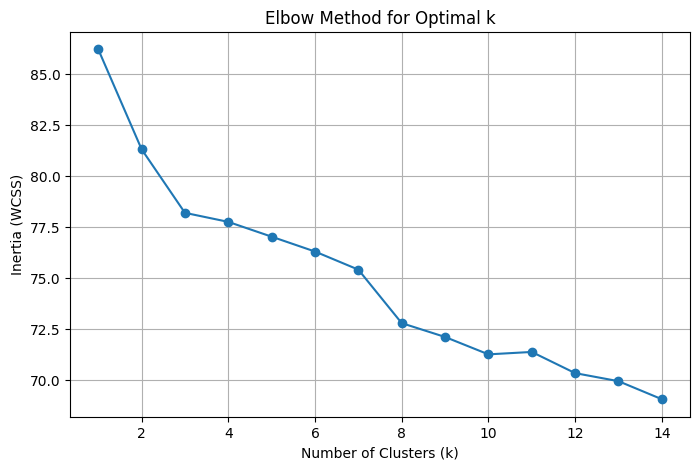

In [ ]:
#plt.figure(figsize=(8, 5))
#plt.plot(k_values, inertia, marker='o')
#plt.xlabel('Number of Clusters (k)')
#plt.ylabel('Inertia (WCSS)')
#plt.title('Elbow Method for Optimal k')
#plt.grid(True)
#plt.show()

In [ ]:
X = group1.drop(columns=['author', 'month_year'])
kmeans = KMeans(n_clusters=3, random_state=42, init="k-means++",)
kmeans.fit(X)
group1["Cluster"] = kmeans.labels_

In [ ]:
group1["Cluster"].value_counts()

,count
Cluster,
1,107
0,60
2,3


### For Visualization TSNE

In [ ]:
#model = TSNE(n_components=2, learning_rate='auto',
#                  init='random', perplexity=3)

In [ ]:
#tsne = TSNE(n_components=2, perplexity=15, random_state=42, init="random", learning_rate=200)
#vis_dims2 = tsne.fit_transform(X)

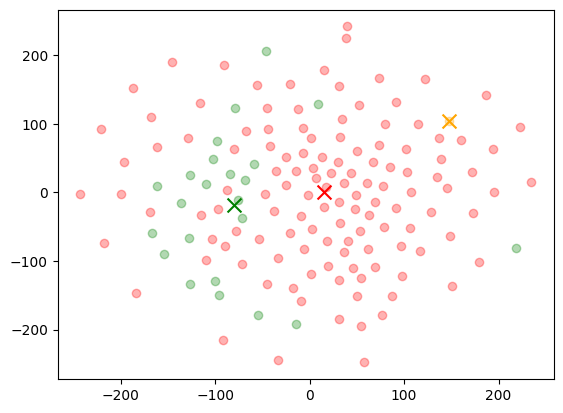

In [ ]:
#x = [x for x, y in vis_dims2]
#y = [y for x, y in vis_dims2]

#for category, color in enumerate(["orange", "green", "red", "blue"]):
#    xs = np.array(x)[group1.Cluster == category ]
#    ys = np.array(y)[group1.Cluster == category ]
#    plt.scatter(xs, ys, color=color, alpha=0.3)

#    avg_x = xs.mean()
#    avg_y = ys.mean()

#    plt.scatter(avg_x, avg_y, marker="x", color=color, s=100)
# plt.title("Clusters identified visualized in language 2d using t-SNE")


In [ ]:
submissions = submissions.rename(columns={'id': 'post_id'})
comments = comments.rename(columns={'author': 'comment_author'})
submissions['month_year'] =  pd.to_datetime(submissions['created']).dt.to_period("M")
full_merge = submissions.merge(comments, left_on='name', right_on='parent_id', how='left')[['post_id', 'author', 'comment_author', 'month_year']]
one_month = full_merge.loc[full_merge['month_year'] == '2023-03']
#users_to_keep = list(selected_authors['author'])
users_to_keep = list(subset_grouped_content['author'].unique())
result = one_month.groupby('post_id').apply(lambda x: set(set(x['author'].dropna().tolist() + x['comment_author'].dropna().tolist()) & set(users_to_keep))).reset_index(name='unique_users')
result = result[result['unique_users'].map(len) > 0]

In [ ]:
# G = nx.Graph()

# # Iterate through each row of unique_users and add edges between all pairs
# for users in result['unique_users']:
#     user_list = list(users)  # if it's a set
#     if len(user_list) > 1:
#         edges = combinations(user_list, 2)
#         G.add_edges_from(edges)

# # Optional: check graph info
# # print(nx.info(G))
# plt.figure(figsize=(15, 15))

# # unique_clusters = list(set(kmeans.labels_))
# # color_map = {cluster: plt.cm.Set1(i / len(unique_clusters)) for i, cluster in enumerate(unique_clusters)}

# # node_colors = [color_map[cluster] for cluster in kmeans.labels_]

# # nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=800, font_size=12)

# # nx.draw(G, pos, with_labels=True,  edge_color='gray', node_size=800, font_size=12)

# nx.draw(G, with_labels=False, node_size=500,
#         # node_color=node_colors,
#         font_size=8, pos=nx.spring_layout(G))
# plt.show()

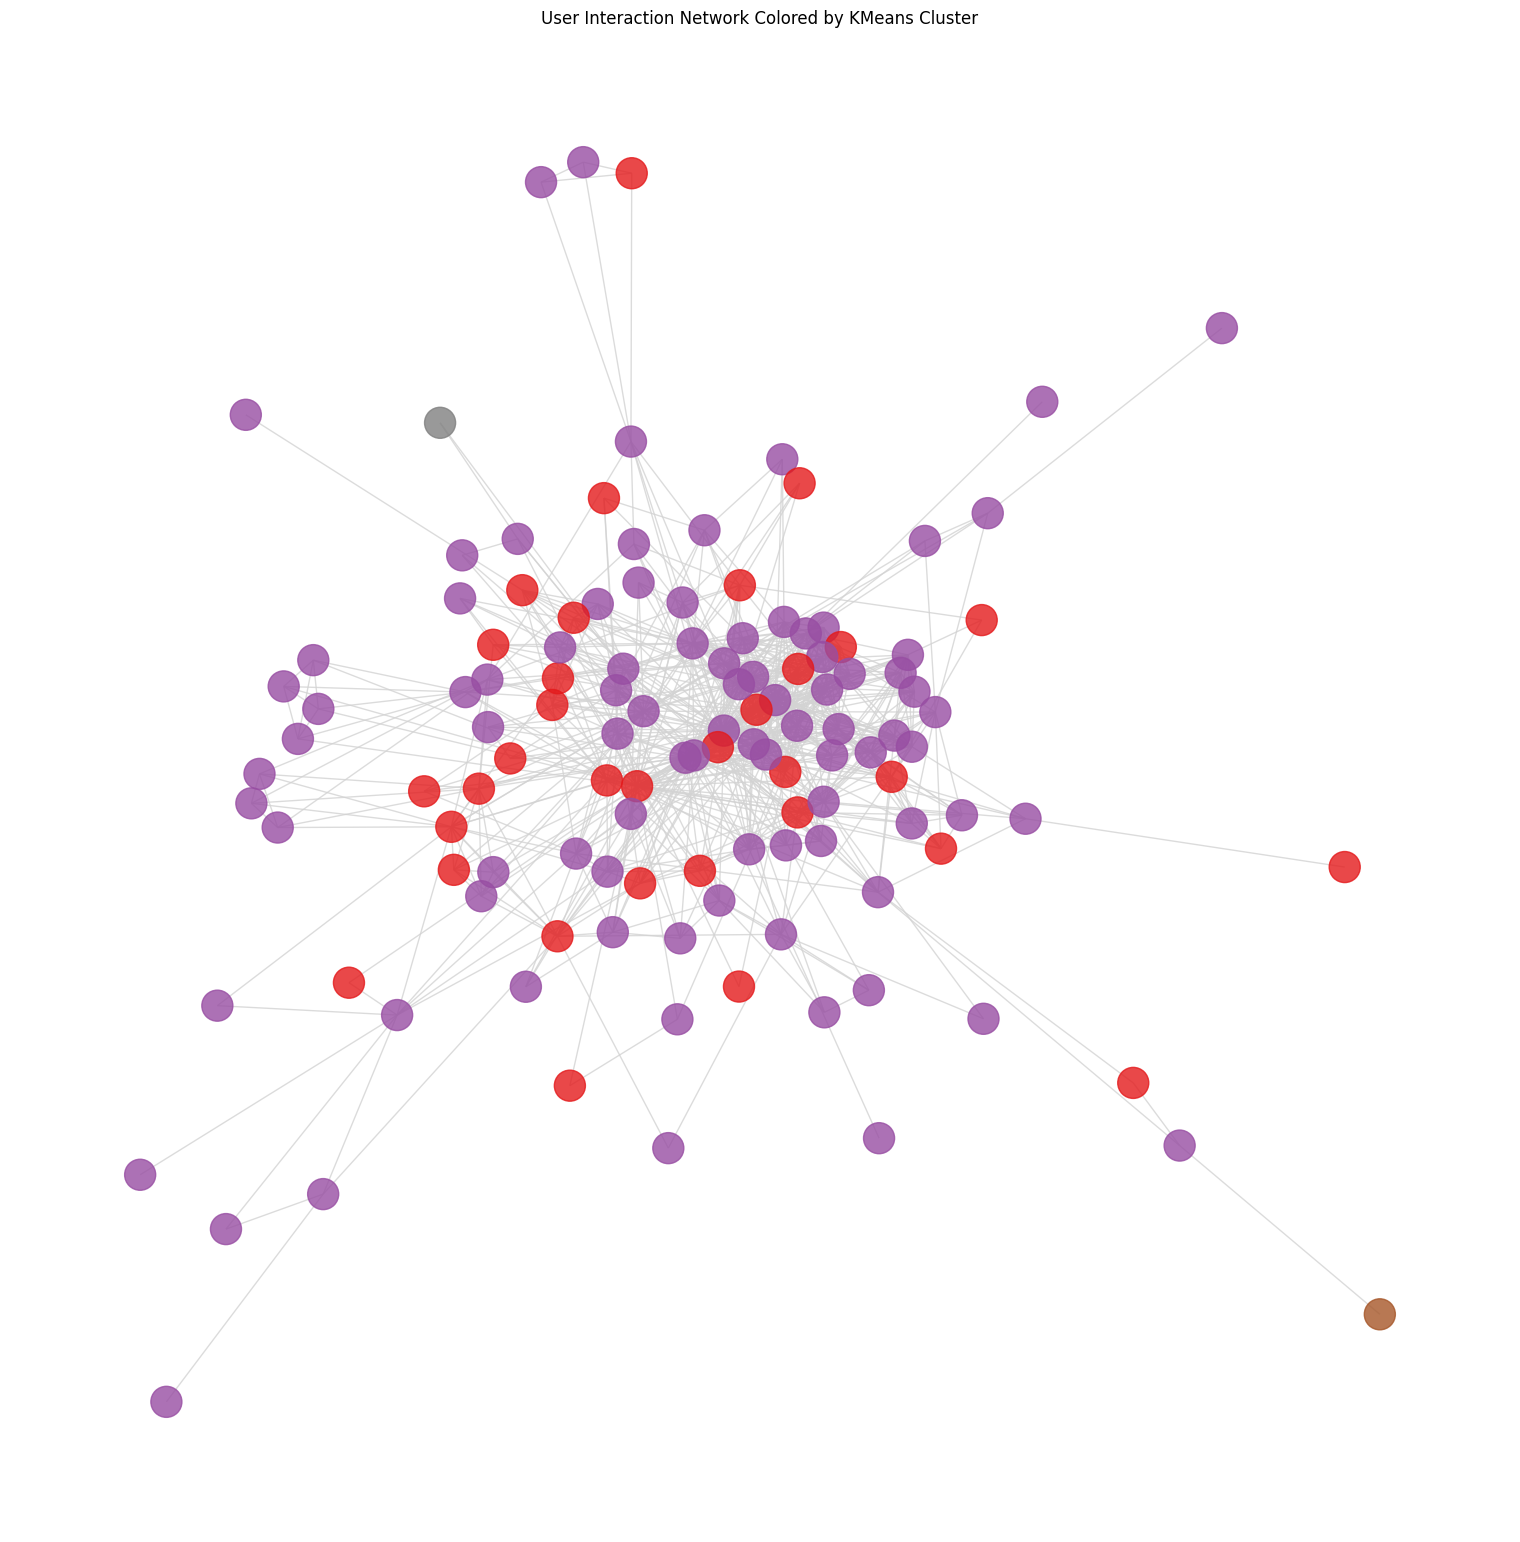

In [ ]:
#user_clusters = group1[['author', 'Cluster']]

# Step 2: Build your user interaction network
#G = nx.Graph()

#for users in result['unique_users']:
#    user_list = list(users)
#    if len(user_list) > 1:
#        edges = combinations(user_list, 2)
#        G.add_edges_from(edges)

# Step 3: Set cluster as node attribute
#user_cluster_dict = dict(zip(user_clusters['author'], user_clusters['Cluster']))
#nx.set_node_attributes(G, user_cluster_dict, name='Cluster')

# Step 4: Assign colors based on cluster
#unique_clusters = list(set(kmeans.labels_))
#color_map = {cluster: plt.cm.Set1(i / len(unique_clusters)) for i, cluster in enumerate(unique_clusters)}

# Some users might not have a cluster (e.g. not in the KMeans data)
#node_colors = [color_map.get(G.nodes[n].get('Cluster'), 'gray') for n in G.nodes()]

# Step 5: Draw graph
#plt.figure(figsize=(15, 15))
#pos = nx.spring_layout(G, seed=42)

#nx.draw(
#    G, pos,
#    with_labels=False,
#    node_color=node_colors,
#    edge_color='lightgray',
#    node_size=500,
#    alpha=0.8
#)

#plt.title("User Interaction Network Colored by KMeans Cluster")
#plt.show()

In [ ]:
#user_clusters

,author,Cluster
20,u/Abject-Interaction35,1
28,u/AlarmDozer,1
39,u/Aliaa_123,0
45,u/Alternative-Reason13,0
57,u/Amazing_Library_5045,1
...,...,...
2491,u/unikornlover,1
2527,u/xeneks,1
2544,u/yonasismad,1
2554,u/yoshhash,1


In [ ]:
# Check for nodes without a cluster
#missing = [n for n in G.nodes() if 'Cluster' not in G.nodes[n]]
#print("Nodes without cluster:", missing)
#G.remove_nodes_from(missing)


Nodes without cluster: ['u/seewallwest']


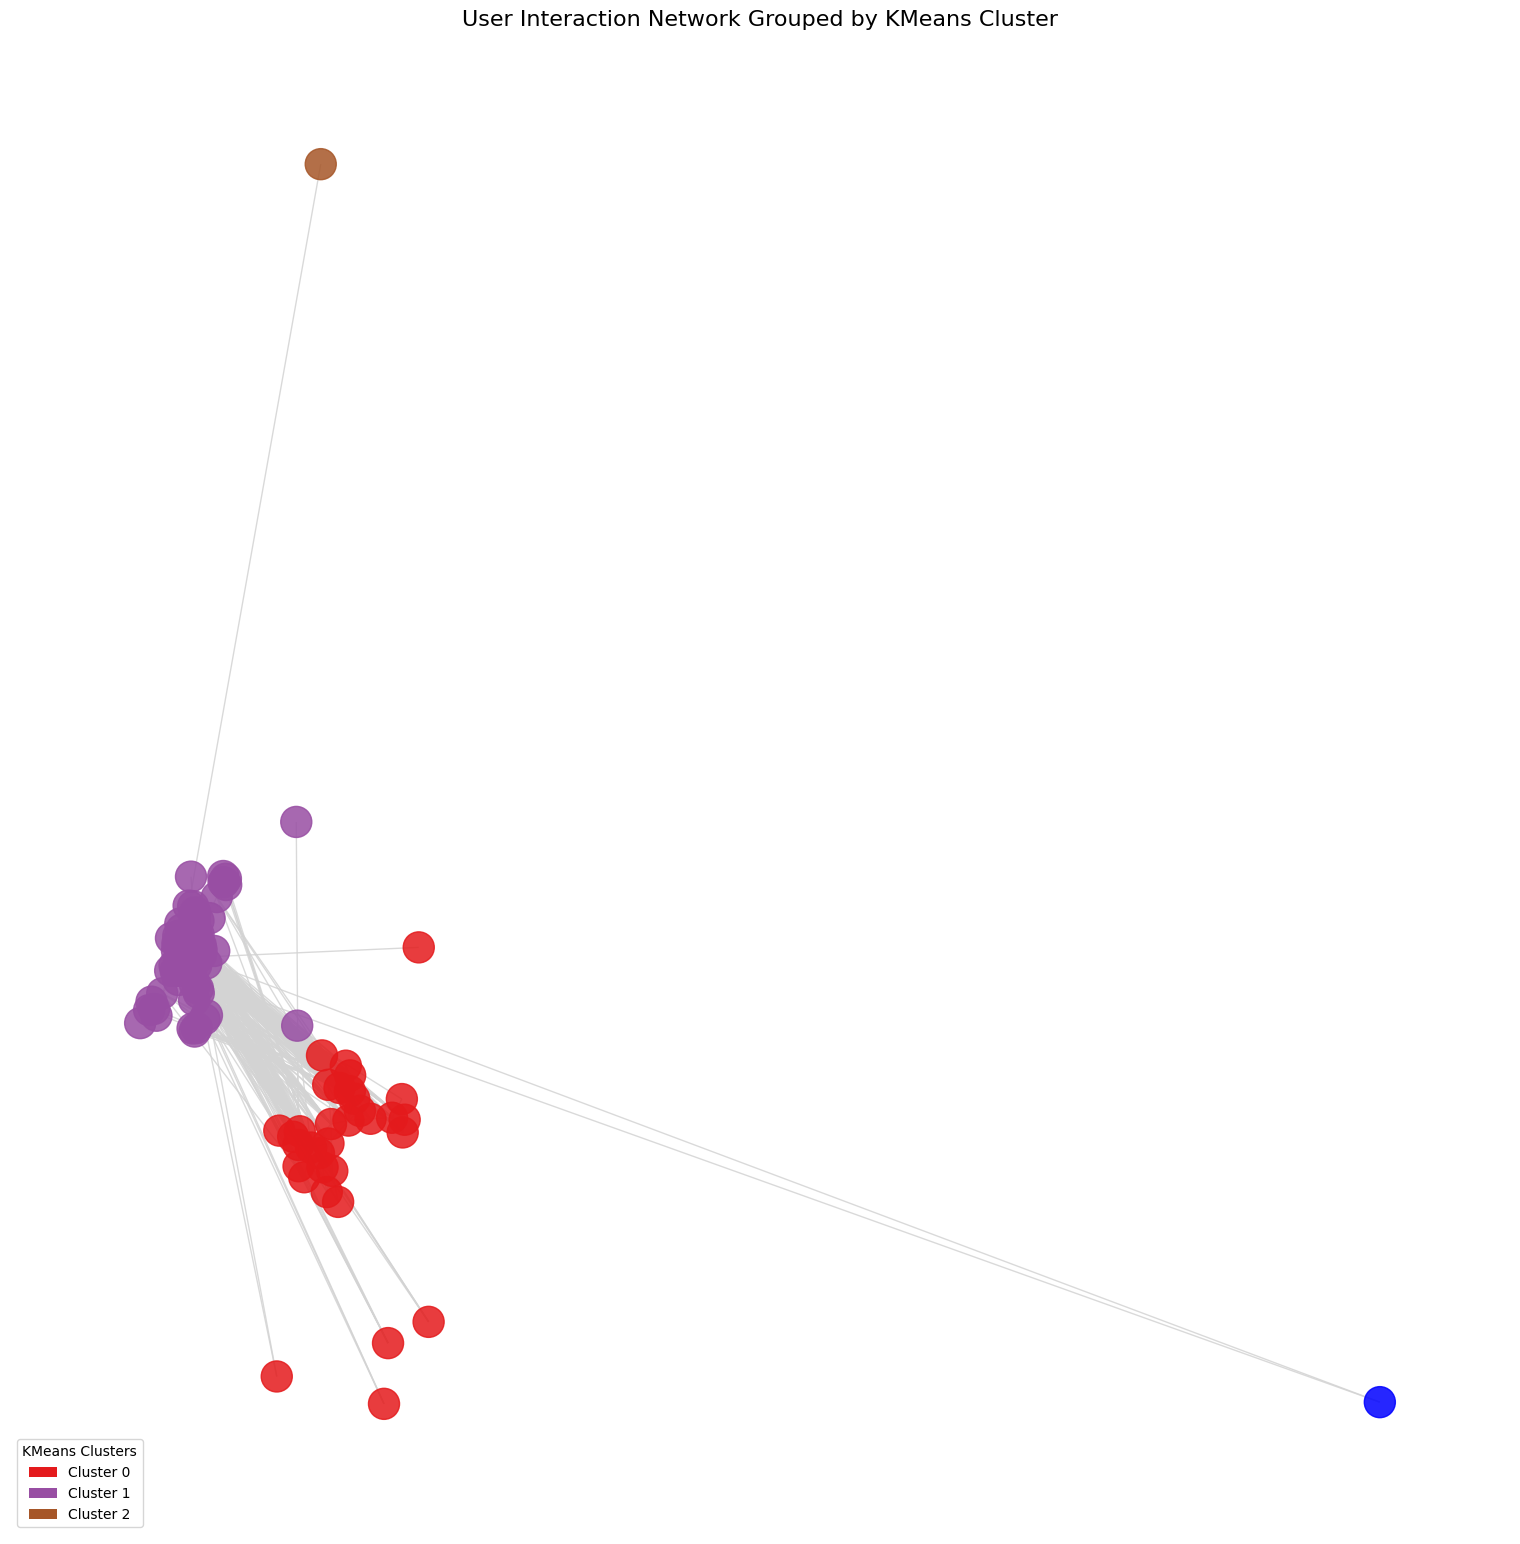

In [ ]:
#import numpy as np
#import matplotlib.pyplot as plt
#import networkx as nx
#from itertools import combinations


# group1 = subset_grouped_content.loc[subset_grouped_content['month_year'] == '2023-08']
# Step 1: Prepare cluster mapping
#user_clusters = group1[['author', 'Cluster']]

# Step 2: Build the user interaction network
#G = nx.Graph()

#for users in result['unique_users']:
#    user_list = list(users)
#    if len(user_list) > 1:
#        edges = combinations(user_list, 2)
#        G.add_edges_from(edges)

# Step 3: Set cluster as node attribute
#user_cluster_dict = dict(zip(user_clusters['author'], user_clusters['Cluster']))
# Filter only users that exist in the graph
#user_cluster_dict = {
#    author: cluster
#    for author, cluster in zip(user_clusters['author'], user_clusters['Cluster'])
#    if author in G.nodes()
#}

#nx.set_node_attributes(G, user_cluster_dict, name='Cluster')

# Step 4: Assign colors based on cluster
#unique_clusters = sorted(set(kmeans.labels_))
#color_map = {cluster: plt.cm.Set1(i / len(unique_clusters)) for i, cluster in enumerate(unique_clusters)}
#node_colors = [color_map.get(G.nodes[n].get('Cluster'), 'blue') for n in G.nodes()]

# === NEW Step 5: Position nodes by cluster group ===
#clusters = nx.get_node_attributes(G, 'Cluster')
#rng = np.random.default_rng(seed=42)
#cluster_positions = {c: np.random.rand(2) * 10 for c in unique_clusters}  # cluster centroids

# Calculate spring layout within each cluster, offset by cluster center
#pos = {}
#for cluster in unique_clusters:
#    cluster_nodes = [n for n, attr in clusters.items() if attr == cluster]
#    subG = G.subgraph(cluster_nodes)
#    sub_pos = nx.spring_layout(subG, seed=42)

#    offset = cluster_positions[cluster]
#    for node, coords in sub_pos.items():
#        pos[node] = coords + offset

# Fallback for unclustered nodes
#for node in G.nodes():
#    if node not in pos:
#        pos[node] = np.random.rand(2) * 20

# Step 6: Draw the graph
#plt.figure(figsize=(15, 15))
#nx.draw(
#    G, pos,
#    with_labels=False,
#    node_color=node_colors,
#    edge_color='lightgray',
#    node_size=500,
#    alpha=0.85
#)
# Add legend for clusters
#from matplotlib.patches import Patch

#legend_elements = [
#    Patch(facecolor=color_map[cluster], label=f'Cluster {cluster}')
#    for cluster in unique_clusters
#]

#plt.legend(handles=legend_elements, title='KMeans Clusters', loc='lower left')

#plt.title("User Interaction Network Grouped by KMeans Cluster", fontsize=16)
#plt.show()

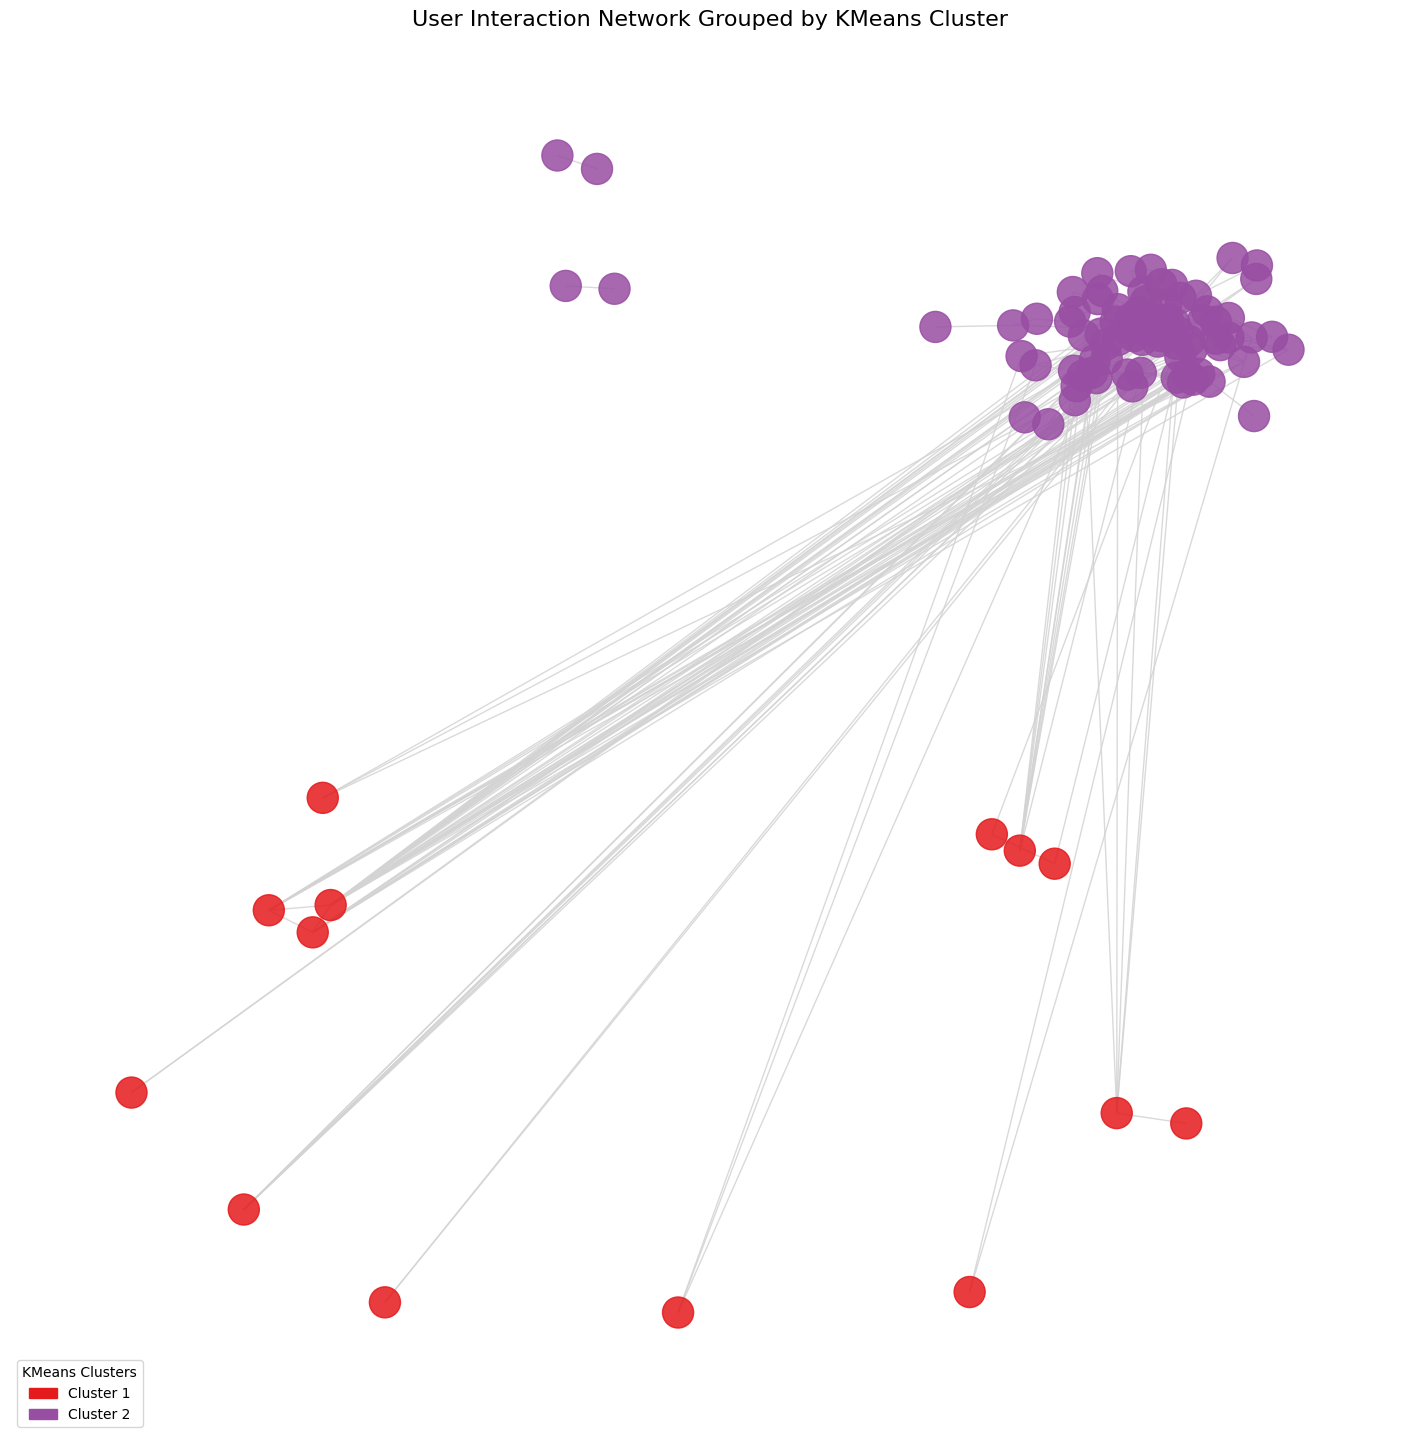

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from itertools import combinations

# === Settings ===
SEED = 42
NUM_CLUSTERS = 3  # or len(set(kmeans.labels_)) if dynamic

# === Step 1: Prepare cluster mapping ===
user_clusters = group1[['author', 'Cluster']]
user_cluster_dict = dict(zip(user_clusters['author'], user_clusters['Cluster']))

# === Step 2: Build the user interaction network ===
G = nx.Graph()

for users in result['unique_users']:
    user_list = list(users)
    if len(user_list) > 1:
        G.add_edges_from(combinations(user_list, 2))

# === Step 3: Assign clusters to nodes ===
nx.set_node_attributes(G, user_cluster_dict, name='Cluster')

# === Step 4: Remove unclustered nodes ===
unclustered = [n for n in G.nodes() if 'Cluster' not in G.nodes[n]]
G.remove_nodes_from(unclustered)

# === Step 5: Define cluster colors ===
unique_clusters = sorted(set(nx.get_node_attributes(G, 'Cluster').values()))
color_map = {
    cluster: plt.cm.Set1(i / NUM_CLUSTERS)
    for i, cluster in enumerate(unique_clusters)
}
node_colors = [color_map[G.nodes[n]['Cluster']] for n in G.nodes()]

# === Step 6: Position nodes by cluster using spring layout + offset ===
rng = np.random.default_rng(SEED)
cluster_positions = {c: rng.random(2) * 10 for c in unique_clusters}
pos = {}

for cluster in unique_clusters:
    nodes_in_cluster = [n for n in G.nodes() if G.nodes[n]['Cluster'] == cluster]
    subG = G.subgraph(nodes_in_cluster)
    sub_pos = nx.spring_layout(subG, seed=SEED)

    offset = cluster_positions[cluster]
    for node, coords in sub_pos.items():
        pos[node] = coords + offset

# === Step 7: Draw the graph ===
plt.figure(figsize=(14, 14))
nx.draw(
    G, pos,
    with_labels=False,
    node_color=node_colors,
    edge_color='lightgray',
    node_size=500,
    alpha=0.85
)

# === Step 7.5: Annotate clusters with top phrases ===
#for cluster in unique_clusters:
#    offset = cluster_positions[cluster]  # Position of the cluster layout
#    phrases = top_phrases.get(cluster, [])

    # Format phrases into a multiline string
#    phrase_text = "\n".join([f"- {p[0]}" for p in phrases])

    # Adjust label position slightly above the cluster
#    label_pos = offset + np.array([0, 2])

#    plt.text(
#        label_pos[0], label_pos[1],
#        f"Cluster {cluster}:\n{phrase_text}",
#        fontsize=10,
#        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.4', alpha=0.7)
#    )


# === Step 8: Add legend ===
from matplotlib.patches import Patch
legend_handles = [
    Patch(color=color_map[c], label=f'Cluster {c}')
    for c in unique_clusters
]
plt.legend(handles=legend_handles, title="KMeans Clusters", loc='lower left')

plt.title("User Interaction Network Grouped by KMeans Cluster", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()


### Cluster shifts

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans

# Assuming your combined data is in `subset_grouped_content`
# and it has columns: 'author', 'month_year', plus 128-dim embeddings

# List of 6 months you're interested in
months = ['2023-01', '2023-02', '2023-03', '2023-04', '2023-05', '2023-06', '2023-07', '2023-08', '2023-09', '2023-10', '2023-11', '2023-12']

# Collect clustering results
clustered_data = []

for month in months:
    group = subset_grouped_content.loc[subset_grouped_content['month_year'] == month].copy()
    X = group.drop(columns=['author', 'month_year'])

    kmeans = KMeans(n_clusters=3, random_state=42, init="k-means++")
    kmeans.fit(X)

    group['Cluster'] = kmeans.labels_
    group['month_year'] = month  # Ensure consistent format
    clustered_data.append(group[['author', 'month_year', 'Cluster']])

# Combine all months into one DataFrame
all_clustered_data = pd.concat(clustered_data, ignore_index=True)

# Pivot to create user_cluster_history
user_cluster_history = all_clustered_data.pivot_table(
    index='author',
    columns='month_year',
    values='Cluster',
    aggfunc='first'
).reset_index()

user_cluster_history.columns.name = None

In [ ]:
import plotly.graph_objects as go
import pandas as pd

def plot_sankey_with_missing(user_cluster_df, month_list):
    df_filled = user_cluster_df.copy()

    # Fill NaNs with string "Missing"
    df_filled[month_list] = df_filled[month_list].fillna("Inactive").astype(str)

    labels = []
    label_to_index = {}
    sources = []
    targets = []
    values = []

    # Create unique labels for each month-cluster pair
    for month in month_list:
        unique_values = sorted(df_filled[month].unique())
        for val in unique_values:
            label = f"{month} - C{val}"
            if label not in label_to_index:
                label_to_index[label] = len(labels)
                labels.append(label)

    # Create flows between consecutive months
    for i in range(len(month_list) - 1):
        month_from = month_list[i]
        month_to = month_list[i + 1]

        flow_counts = df_filled.groupby([month_from, month_to]).size().reset_index(name='count')

        for _, row in flow_counts.iterrows():
            src_label = f"{month_from} - C{row[month_from]}"
            tgt_label = f"{month_to} - C{row[month_to]}"
            sources.append(label_to_index[src_label])
            targets.append(label_to_index[tgt_label])
            values.append(row['count'])

    # Plot Sankey diagram
    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=15,
            thickness=20,
            line=dict(color="black", width=0.5),
            label=labels
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values
        ))])

    fig.update_layout(title_text="User Cluster Transitions Over Months", font_size=12)
    fig.show()

months_to_use = ['2023-01', '2023-02', '2023-03', '2023-04', '2023-05', '2023-06', '2023-07', '2023-08', '2023-09', '2023-10', '2023-11', '2023-12']
plot_sankey_with_missing(user_cluster_history, months_to_use)


### Keywords

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import re
import string

# Step 1: Merge cluster labels with all_content
group1_filtered = group1[['author', 'month_year', 'Cluster']]
group1_filtered['month_year'] = group1_filtered['month_year'].astype(str)  # Ensure matchable format

# Also make sure 'month_year' in all_content is in string format for merging
all_content['month_year'] = all_content['month_year'].astype(str)

merged = pd.merge(all_content, group1_filtered, on=['author', 'month_year'], how='inner')

# Step 2: Preprocess and combine text
def clean_text(text):
    if pd.isnull(text):
        return ""
    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)
    return text

merged['combined_text'] = merged['title'].fillna('') + " " + merged['selftext'].fillna('') + " " + merged['text'].fillna('') + " " + merged['body'].fillna('')
merged['clean_text'] = merged['combined_text'].apply(clean_text)

# Step 3: Function to extract top key phrases for each cluster
def extract_top_phrases(df, cluster_col='Cluster', text_col='clean_text', top_n=5):
    top_phrases_per_cluster = {}

    for cluster in sorted(df[cluster_col].unique()):
        cluster_texts = df[df[cluster_col] == cluster][text_col].tolist()

        # TF-IDF Vectorizer for bi-grams and tri-grams
        vectorizer = TfidfVectorizer(ngram_range=(2, 3), max_features=1000, stop_words='english')
        tfidf_matrix = vectorizer.fit_transform(cluster_texts)

        # Sum scores for each phrase
        phrase_scores = np.asarray(tfidf_matrix.sum(axis=0)).flatten()
        phrases = vectorizer.get_feature_names_out()

        top_indices = phrase_scores.argsort()[::-1][:top_n]
        top_phrases = [(phrases[i], phrase_scores[i]) for i in top_indices]
        top_phrases_per_cluster[cluster] = top_phrases

    return top_phrases_per_cluster

# Step 4: Run and view
top_phrases = extract_top_phrases(merged)

# Print out top phrases for each cluster
for cluster, phrases in top_phrases.items():
    print(f"\nCluster {cluster} Top Phrases:")
    for phrase, score in phrases:
        print(f"{phrase} (score: {score:.4f})")



Cluster 0 Top Phrases:
climate change (score: 9.9193)
sea level (score: 2.7370)
fossil fuel (score: 2.4396)
air pollution (score: 2.4185)
billion people (score: 2.2194)

Cluster 1 Top Phrases:
climate change (score: 44.9769)
sea level (score: 15.7956)
fossil fuels (score: 9.7740)
years ago (score: 9.0733)
fossil fuel (score: 8.8952)

Cluster 2 Top Phrases:
stable live (score: 1.0000)
don kids (score: 1.0000)
tightly twiggy (score: 0.4472)
tech tightly (score: 0.4472)
tech tightly twiggy (score: 0.4472)


### Semantic Keywords

In [ ]:
!pip install keybert

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.7/345.7 kB 9.2 MB/s eta 0:00:00


In [ ]:
!pip install sentence-transformers

In [ ]:
from keybert import KeyBERT
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import re

# Step 1: Clean text
def clean_text(text):
    if pd.isnull(text):
        return ""
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r"[^\w\s]", "", text)
    return text

merged['combined_text'] = merged['title'].fillna('') + " " + \
                          merged['selftext'].fillna('') + " " + \
                          merged['text'].fillna('') + " " + \
                          merged['body'].fillna('')
merged['clean_text'] = merged['combined_text'].apply(clean_text)

# Step 2: Initialize KeyBERT model
kw_model = KeyBERT(model='paraphrase-MiniLM-L6-v2')  # You can use others too

# Step 3: Extract top key phrases per cluster
cluster_phrases = {}

for cluster in sorted(merged['Cluster'].unique()):
    cluster_df = merged[merged['Cluster'] == cluster]
    full_text = " ".join(cluster_df['clean_text'].tolist())

    keywords = kw_model.extract_keywords(
        full_text,
        keyphrase_ngram_range=(2, 3),
        stop_words='english',
        top_n=10,
        use_maxsum=True,
        nr_candidates=30
    )

    cluster_phrases[cluster] = keywords

# Step 4: Display
for cluster, phrases in cluster_phrases.items():
    print(f"\n🔹 Cluster {cluster} Top Key Phrases:")
    for phrase, score in phrases:
        print(f"• {phrase} (score: {score:.4f})")


#### AnglE Model

In [ ]:
#angle = AnglE.from_pretrained('WhereIsAI/UAE-Large-V1', pooling_strategy='cls').cuda()
#texts = list(submissions['scoring_text'])  # full list or slice
#batch_size = 8
#all_vecs = []

#for i in range(0, len(texts), batch_size):
#    batch = texts[i:i + batch_size]
#    batch_vecs = angle.encode(batch)
#    all_vecs.append(batch_vecs)
#doc_vecs = np.vstack(all_vecs)
#embedding_df = pd.DataFrame(doc_vecs)
#submissions_embed = pd.concat([submissions, embedding_df], axis=1)
#submissions_embed.to_csv('./submissions_climate_change_embed.csv', index=False)

In [ ]:
#texts = list(comments['body'])  # full list or slice
#batch_size = 8
#all_vecs = []

#for i in tqdm(range(0, len(texts), batch_size)):
#    batch = texts[i:i + batch_size]
#    batch_vecs = angle.encode(batch)
#    all_vecs.append(batch_vecs)

# submissions_embed = pd.concat([submissions, embedding_df], axis=1)
# submissions_embed.to_csv('./submissions_climate_change_embed.csv', index=False)

In [ ]:
#doc_vecs = np.vstack(all_vecs)
#embedding_df = pd.DataFrame(doc_vecs)

In [ ]:
#comments_embed = pd.concat([comments, embedding_df], axis=1)

In [ ]:
#comments_embed = comments_embed.loc[comments_embed['author'] != 'u/[deleted]']

In [ ]:
#comments_embed = comments_embed.reset_index(drop=True)

In [ ]:
#month_year = dt_series.dt.to_period("M")

In [ ]:
#comments_embed['month_year'] = pd.to_datetime(comments_embed['created']).dt.to_period("M")

In [ ]:
#submissions_embed = submissions_embed.loc[submissions_embed['author'] != 'u/[deleted]']

In [ ]:
#submissions_embed['author'].nunique()

2886



Needs to be done
- Combine both submissions and comments
- group by user and month and calculate average embedding
- performing clustering

For visualization
- left merge submissions and comments
- get all users appearing in a single submission -post combination
- plot network graph and then
- hypergraph on top of it based on k-means

K-means

In [ ]:
#submissions_embed.shape

(5630, 1041)

In [ ]:
#submissions_embed['author'].value_counts()

author
u/boppinmule              151
u/sylvyrfyre              112
u/Alternative-Reason13     95
u/Tpaine63                 84
u/shallah                  62
                         ... 
u/MrDavidP                  1
u/Will_Heavy                1
u/WonderingDetective        1
u/writesforu                1
u/naastiknibba95            1
Name: count, Length: 2886, dtype: int64

In [ ]:
#submissions_embed.groupby(['author', 'month_year'])['0'].mean().reset_index()

,author,month_year,0
0,u/-NJProd-,2023-08,-0.300789
1,u/-Ohhh-,2023-07,0.333258
2,u/-Ohhh-,2023-08,-0.130704
3,u/-Ohhh-,2023-11,-0.662299
4,u/-One-Eye-Jack-,2023-01,0.399034
...,...,...,...
3637,u/zubairlatifbhatti,2023-10,-0.370978
3638,u/zucarritas,2023-03,-0.982729
3639,u/zutnn,2023-02,0.063344
3640,u/zutnn,2023-06,0.222993


In [ ]:
#comments_embed['author'].nunique()

21220

In [ ]:
#grouped_comments = comments_embed.groupby(['author', 'month_year'])[embedding_df.columns].mean().reset_index()

In [ ]:
#author_count = grouped_comments['author'].value_counts().reset_index()

In [ ]:
#author_count.shape

(21220, 2)

In [ ]:
#author_count.loc[author_count['count'] >= 6]

,author,count
0,u/technologyisnatural,13
1,u/lightweight12,12
2,u/NotTheBusDriver,12
3,u/shanem,12
4,u/bdginmo,12
...,...,...
305,u/Paleocene83,6
306,u/bigone242,6
307,u/No_Combination_649,6
308,u/Bella_madera,6


In [ ]:
#X = comments_embed[comments_embed.columns[13:]]

In [ ]:
#kmeans.fit(X)

KMeans(n_clusters=4, random_state=42)

In [ ]:
#labels = kmeans.labels_
#comments_embed["Cluster"] = labels + 1

In [ ]:
#comments_embed["Cluster"].value_counts()

Cluster
3    43649
4    34863
1    32353
2    27069
Name: count, dtype: int64

In [ ]:
# X_embedded = model.fit_transform(X)

In [ ]:
#model.pre

(137934, 2)

In [ ]:
#sampled = comments_embed.sample(frac=0.005, weights='Cluster')

In [ ]:
#sampled['Cluster'].value_counts()

Cluster
3    256
4    256
2    121
1     57
Name: count, dtype: int64

In [ ]:
#sampled_X = sampled[sampled.columns[13:]]
#sampled_X = sampled_X.drop(columns=['Cluster'])

In [ ]:
#tsne = TSNE(n_components=2, perplexity=15, random_state=42, init="random", learning_rate=200)
#vis_dims2 = tsne.fit_transform(sampled_X)

Text(0.5, 1.0, 'Clusters identified visualized in language 2d using t-SNE')

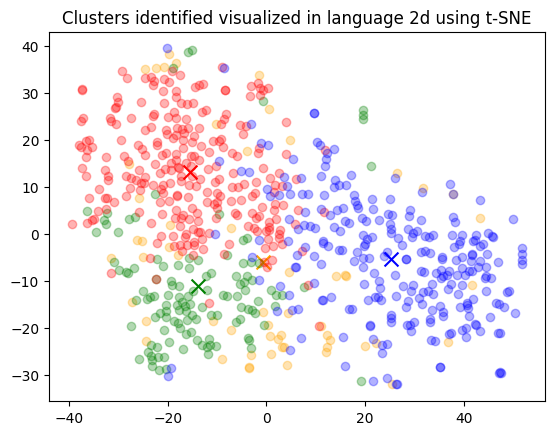

In [ ]:
#x = [x for x, y in vis_dims2]
#y = [y for x, y in vis_dims2]

#for category, color in enumerate(["orange", "green", "red", "blue"]):
#    xs = np.array(x)[sampled.Cluster == category + 1]
#    ys = np.array(y)[sampled.Cluster == category + 1]
#    plt.scatter(xs, ys, color=color, alpha=0.3)

#    avg_x = xs.mean()
#    avg_y = ys.mean()

#    plt.scatter(avg_x, avg_y, marker="x", color=color, s=100)
#plt.title("Clusters identified visualized in language 2d using t-SNE")


In [ ]:
# for non-retrieval tasks, we don't need to specify prompt when using UAE-Large-V1.


# for i, dv1 in enumerate(doc_vecs):
#     for dv2 in doc_vecs[i+1:]:
#         print(cosine_similarity(dv1, dv2))